<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Day_8_Phylogenetic_Tree_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.9 MB/s eta 0:00:00


In [ ]:
!pip install jupyter_bokeh

In [ ]:
import random
import numpy as np

from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import MultipleSeqAlignment
from Bio.Phylo.TreeConstruction import DistanceCalculator
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor
from Bio import Phylo
from io import StringIO

import re

import panel as pn
import panel.widgets as pnw
pn.extension()

from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, Plot, Grid, Range1d
from bokeh.models.glyphs import Text, Rect
from bokeh.layouts import gridplot

In [ ]:
# substitute a random base in a sequence n times

def mutate_n(dna, N):
    dna = np.array(dna, dtype='c')  # array of characters
    mutation_sites = random.sample(range(0, len(dna) - 1), N)
    # Draw new bases - 1 in 4 chance of no mutation
    new_bases = random.choices(list('ATCG'), k=N)
    # Replace the mutated bases
    dna[mutation_sites] = new_bases
    return ''.join([bytes.decode(s) for s in np.frombuffer(dna, dtype='S1')])

In [ ]:
# visualize a sequence alignment
# adapted from https://dmnfarrell.github.io/bioinformatics/bokeh-sequence-aligner

import panel as pn
import panel.widgets as pnw
pn.extension()

from bokeh.plotting import figure
from bokeh.models import ColumnDataSource, Plot, Grid, Range1d
from bokeh.models.glyphs import Text, Rect
from bokeh.layouts import gridplot

def view_alignment(aln, fontsize="9pt", width=800):
    """Bokeh sequence alignment view"""

    #make sequence and id lists from the aln object
    seqs = [rec.seq for rec in (aln)]
    ids = [rec.id for rec in aln]
    text = [i for s in list(seqs) for i in s]
    colors = get_colors(seqs)
    N = len(seqs[0])
    S = len(seqs)
    # width = .4  <-- This line is commented out as it redefines width locally after it's used as a parameter

    x = np.arange(0.5,N+0.5)
    y = np.arange(0,S,1)
    #creates a 2D grid of coords from the 1D arrays
    xx, yy = np.meshgrid(x, y)
    #flattens the arrays
    gx = xx.ravel()
    gy = yy.flatten()
    #use recty for rect coords with an offset
    recty = gy+.5
    h= 1/S
    #now we can create the ColumnDataSource with all the arrays
    source = ColumnDataSource(dict(x=gx, y=gy, recty=recty, text=text, colors=colors))
    plot_height = len(seqs)*15+50 # Keep calculating plot_height as it's used below
    x_range = Range1d(0,N+1, bounds='auto')
    if N>100:
        viewlen=100
    else:
        viewlen=N
    #view_range is for the close up view
    view_range = (0,viewlen)
    tools="xpan, xwheel_zoom, reset, save"

    #sequence text view with ability to scroll along x axis
    p = figure(title=None, width=width, height=plot_height,
                x_range=view_range, y_range=ids, tools="xpan,reset",
                min_border=0, toolbar_location='below')#, lod_factor=1)
    glyph = Text(x="x", y="y", text="text", text_align='center',text_color="black",
                text_font="monospace",text_font_size=fontsize)
    rects = Rect(x="x", y="recty",  width=1, height=1, fill_color="colors",
                line_color=None, fill_alpha=0.4)
    p.add_glyph(source, glyph)
    p.add_glyph(source, rects)

    p.grid.visible = False
    p.xaxis.major_label_text_font_style = "bold"
    p.yaxis.minor_tick_line_width = 0
    p.yaxis.major_tick_line_width = 0

    p = gridplot([[p]], toolbar_location='below')
    return p

def get_colors(seqs):
    """make colors for bases in sequence"""
    text = [i for s in list(seqs) for i in s]
    clrs =  {'A':'red','T':'green','G':'orange','C':'blue','-':'white'}
    colors = [clrs[i] for i in text]
    return colors

In [ ]:
# build a phylogenetic tree from a list of sequences

def build_tree(sequences, method='upgma'):
    alignment = MultipleSeqAlignment(sequences)

    calculator = DistanceCalculator('identity')
    dm = calculator.get_distance(alignment)

    constructor = DistanceTreeConstructor()
    if method == 'upgma':
        tree = constructor.upgma(dm)
    if method == 'nj':
        tree = constructor.nj(dm)

    tree.root_with_outgroup('Ancestor')
    tree.ladderize() # place longer branches on the bottom
    edit_tree = re.sub('Inner\\d+', '', tree.format('newick')) # remove the inner node labels
    handle = StringIO(edit_tree)
    tree = Phylo.read(handle, 'newick')
    Phylo.draw(tree)

    return alignment

In [ ]:
# simulate sequence evolution

def random_DNA(length):
    DNA=""
    for count in range(length):
        DNA+=random.choice("CGTA")
    return DNA

def make_random_seqs(num_mutations):
    seq_recs_random = [SeqRecord(Seq(seq1), id="Ancestor")]
    for i in range(n_seqs):
        num = i + 1
        num_mutations = random.randint(0, 10)
        print('Generating sequence ' + str(num) + ': ' + str(num_mutations) + ' mutations from the Ancestor')
        sequence = mutate_n(seq1, num_mutations)
        seq_recs_random.append(SeqRecord(Seq(sequence), id="Sequence_" + str(num)))
    return seq_recs_random

def make_serial_seqs(num_mutations):
    seq_recs_serial = [SeqRecord(Seq(seq1), id="Ancestor")]
    for i in range(n_seqs):
        num = i + 1
        print('Generating sequence ' + str(num) + ': ' + str(num_mutations) + ' mutations from sequence ' + str(i))
        sequence = mutate_n(str(seq_recs_serial[i].seq), num_mutations)
        seq_recs_serial.append(SeqRecord(Seq(sequence), id="Sequence_" + str(num)))
    return seq_recs_serial

def make_bifurcating_seqs(num_mutations):
    seq_recs_bifurcating = {'Ancestor': SeqRecord(Seq(seq1), id="Ancestor")}
    gen_names = {'0' : ['Ancestor']}

    for gen in range(4): # model four generations
        ids = ['A', 'B']
        ancestors = gen_names[str(gen)]
        names = []
        for ancestor in ancestors:
            offspring = [ancestor + "." + id for id in ids]
            names.extend(offspring)
            for i in offspring:
                sequence = mutate_n(str(seq_recs_bifurcating[ancestor].seq), num_mutations)
                seq_recs_bifurcating[i] = SeqRecord(Seq(sequence), id=i)
        gen_names[str(gen+1)] = names
    seq_recs_bifurcating = list(seq_recs_bifurcating.values())
    return seq_recs_bifurcating

def make_binary_fission(num_mutations, num_gens=4):
    seq_recs_bifurcating = {'Ancestor': SeqRecord(Seq(seq1), id="Ancestor")}
    gen_names = {'0' : ['Ancestor']}

    for gen in range(num_gens): # model num_gens generations
        ancestors = gen_names[str(gen)]
        names = []
        for ancestor in ancestors:
            print('Generating sequences for generation ' + str(gen) + ': ' + str(num_mutations) + ' mutations from the previous generation')
            offspring = [ancestor + 'same', ancestor + 'mut']
            names.extend(offspring)
            seq_recs_bifurcating[offspring[0]] = SeqRecord(Seq(str(seq_recs_bifurcating[ancestor].seq)), id=offspring[0])
            sequence = mutate_n(str(seq_recs_bifurcating[ancestor].seq), num_mutations)
            seq_recs_bifurcating[offspring[1]] = SeqRecord(Seq(sequence), id=offspring[1])
        gen_names[str(gen+1)] = names
    seq_recs_bifurcating = list(seq_recs_bifurcating.values())
    return seq_recs_bifurcating
# Here, we define the DNA sequence of our bacterial ancestor ('seq1'), the number of sequences to generate ('n_seqs'), and the number of mutations to simu

In [ ]:
seq1 = random_DNA(length=40)
print("DNA sequence of our ancestor: " + seq1)
n_seqs = 20
num_mutations = 2 # number of mutations to simulate per step (if applicable)

DNA sequence of our ancestor: CTATGATCGCCTTTCATGGTACCGAAGGGCTCCGTATGCT


Generating sequence 1: 2 mutations from sequence 0
Generating sequence 2: 2 mutations from sequence 1
Generating sequence 3: 2 mutations from sequence 2
Generating sequence 4: 2 mutations from sequence 3
Generating sequence 5: 2 mutations from sequence 4
Generating sequence 6: 2 mutations from sequence 5
Generating sequence 7: 2 mutations from sequence 6
Generating sequence 8: 2 mutations from sequence 7
Generating sequence 9: 2 mutations from sequence 8
Generating sequence 10: 2 mutations from sequence 9
Generating sequence 11: 2 mutations from sequence 10
Generating sequence 12: 2 mutations from sequence 11
Generating sequence 13: 2 mutations from sequence 12
Generating sequence 14: 2 mutations from sequence 13
Generating sequence 15: 2 mutations from sequence 14
Generating sequence 16: 2 mutations from sequence 15
Generating sequence 17: 2 mutations from sequence 16
Generating sequence 18: 2 mutations from sequence 17
Generating sequence 19: 2 mutations from sequence 18
Generating s

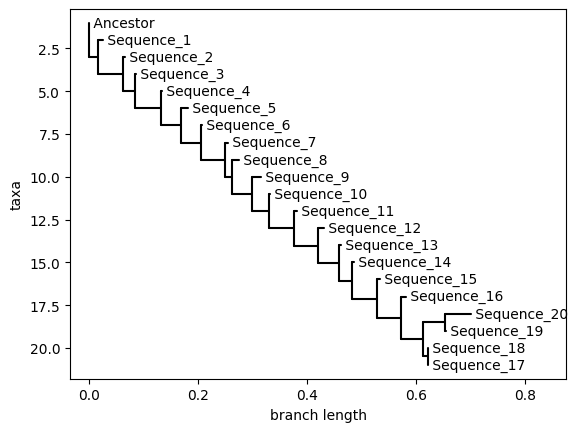

Bokeh(GridPlot)

In [ ]:
#Creating bacteria with a fixed number of mutations compared to their ancestor
sequences = make_serial_seqs(num_mutations)

alignment = build_tree(sequences, method='nj')
p = view_alignment(alignment, width=1200)
pn.pane.Bokeh(p)

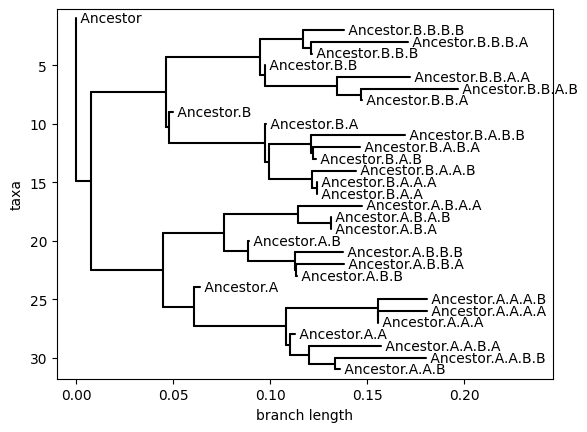

Bokeh(GridPlot)

In [ ]:
sequences = make_bifurcating_seqs(num_mutations)

alignment = build_tree(sequences, method='nj')
p = view_alignment(alignment, width=1200)
pn.pane.Bokeh(p)